In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

###Load Train Dataset

In [ ]:
# emotion.csv

file_link = 'https://drive.google.com/file/d/1RYGc03-OEbLyo4_wgZMSqh_-hfNA-rYg/view?usp=drive_link'
file_id = file_link.split('/d/')[1].split('/')[0]
new_link = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(new_link, sep=';')
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

     id                                               text   emotion lan  \
0  2275       Hands down. You are good. I mean smart good.       joy  EN   
1  2283                     Your are very good. keep it up      none  EN   
2  2292  Man!! I will never get used to these videos of...  surprise  EN   
3  2293                                    ডিসলাইক দেয়া 32      none  BN   
4  2298                                     ব্যাপক বিনোদন।       joy  BN   

        domain  
0  funny_video  
1  funny_video  
2  funny_video  
3  funny_video  
4  funny_video  

Dataset shape: (2890, 5)
Columns: ['id', 'text', 'emotion', 'lan', 'domain']


###Load Test Dataset

In [ ]:
file = 'https://drive.google.com/file/d/123Xhipf8KGIX60cNtePbsrrZp65lKYbj/view?usp=drive_link'
id = file.split('/d/')[1].split('/')[0]
new = f'https://drive.google.com/uc?export=download&id={id}'

# The file uses semicolon (;) as separator, not comma
df = pd.read_csv(new, sep=';')
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

     id                                               text emotion
0  2299                              Osadharon chaliye jao     joy
1  2304                     Shakil Ahmed otai to asol moza    none
2  2387                                     Ore moja paisi     joy
3  2490  Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...     sad
4  2543                     ei video te 1m view howa uchit    none

Dataset shape: (1137, 3)
Columns: ['id', 'text', 'emotion']


# Actual Work with smaller dataset

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
emotion = pd.read_csv("text.csv")

In [ ]:
emotion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  416809 non-null  int64 
 1   text        416809 non-null  object
 2   label       416809 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 9.5+ MB


In [ ]:
emotion['label'].unique()

array([4, 0, 2, 1, 5, 3])

# Dataset Imbalance

In [ ]:
class_counts=emotion.groupby('label').size()
columns=['label','count','percentage']
outcome=[0,1,2,3,4,5]
count=list()
percentage=list()
for val in range(6):
    count.append(class_counts[val])
    percent=(class_counts[val]/len(emotion))*100
    percentage.append(percent)
imbalance_career=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_career

,label,count,percentage
0,0,121187,29.074948
1,1,141067,33.844519
2,2,34554,8.290128
3,3,57317,13.751383
4,4,47712,11.446970
5,5,14972,3.592053


# Data pre-process

In [ ]:
print("Percentage(%) of null values per column:")
print(emotion.isnull().sum()/len(emotion)*100)

Percentage(%) of null values per column:
Unnamed: 0    0.0
text          0.0
label         0.0
dtype: float64


In [ ]:
drop_col = ['Unnamed: 0']
emotion_new = emotion.drop(drop_col, axis=1)
emotion_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [ ]:
# Create a smaller sample of the dataset with equal numbers of all unique labels
emotion_sample = emotion_new.groupby('label').apply(lambda x: x.sample(n=min(len(x), 200), random_state=42)).reset_index(drop=True) # You can change the number of samples per label here

display(emotion_sample.info())
display(emotion_sample['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1200 non-null   object
 1   label   1200 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.9+ KB


/tmp/ipython-input-828622556.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_sample = emotion_new.groupby('label').apply(lambda x: x.sample(n=min(len(x), 200), random_state=42)).reset_index(drop=True) # You can change the number of samples per label here


None

,count
label,
0,200
1,200
2,200
3,200
4,200
5,200


# *Now we use pretrained models to tune it according to this dataset*

In [ ]:
%pip install transformers accelerate

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch

# Load pre-trained tokenizer and model
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(emotion_new['label'].unique()))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Prepare the data for the model
encodings = tokenizer(list(emotion_sample['text']), truncation=True, padding=True, max_length=128)

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long) # Assuming labels are integers
        return item

    def __len__(self):
        return len(self.labels)

dataset = EmotionDataset(encodings, emotion_sample['label'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels to integers
label_encoder = LabelEncoder()
emotion_sample['label'] = label_encoder.fit_transform(emotion_sample['label'])

# Split the dataset into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(list(emotion_sample['text']), emotion_sample['label'], test_size=0.2, random_state=42)

# Tokenize the training and validation texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# Create PyTorch datasets
train_dataset = EmotionDataset(train_encodings, pd.Series(train_labels))
val_dataset = EmotionDataset(val_encodings, pd.Series(val_labels))

In [ ]:
from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # number of training epochs
    per_device_train_batch_size=16,  # batch size for training
    per_device_eval_batch_size=64,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
    eval_strategy="epoch",
    report_to="none" # Corrected argument name
)

In [ ]:
from transformers import Trainer

# Create a Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    tokenizer=tokenizer                  # the tokenizer is needed for the Trainer to know how to handle the data
)

/tmp/ipython-input-2157618189.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.783400,1.781429
2,1.679400,1.661409
3,1.261500,1.214700


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=180, training_loss=1.6581350167592366, metrics={'train_runtime': 937.7841, 'train_samples_per_second': 3.071, 'train_steps_per_second': 0.192, 'total_flos': 48436847596800.0, 'train_loss': 1.6581350167592366, 'epoch': 3.0})

In [ ]:
# Evaluate the model
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 1.2147003412246704, 'eval_runtime': 22.4686, 'eval_samples_per_second': 10.682, 'eval_steps_per_second': 0.178, 'epoch': 3.0}


In [ ]:
from transformers import pipeline

# Create a text classification pipeline using the fine-tuned model
sentiment_analyzer = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Test the pipeline with a sample text
text_to_test = "অমর খুশি লাগতেসে"
result = sentiment_analyzer(text_to_test)

print(f"Text: {text_to_test}")
print(f"Predicted sentiment: {result}")

Device set to use cpu


Text: অমর খুশি লাগতেসে
Predicted sentiment: [{'label': 'LABEL_0', 'score': 0.195460245013237}]


In [ ]:
# Display the mapping between numerical labels and original emotion labels
label_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
print("Label mapping:")
print(label_mapping)

Label mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}


## *other models*

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load pre-trained tokenizer and model
tokenizer_1 = AutoTokenizer.from_pretrained("xlm-roberta-base")
model_1 = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=len(emotion_new['label'].unique()))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Prepare the data for the model
encodings = tokenizer_1(list(emotion_sample['text']), truncation=True, padding=True, max_length=128)

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long) # Assuming labels are integers
        return item

    def __len__(self):
        return len(self.labels)

dataset = EmotionDataset(encodings, emotion_sample['label'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels to integers
label_encoder = LabelEncoder()
emotion_sample['label'] = label_encoder.fit_transform(emotion_sample['label'])

# Split the dataset into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(list(emotion_sample['text']), emotion_sample['label'], test_size=0.2, random_state=42)

# Tokenize the training and validation texts
train_encodings = tokenizer_1(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer_1(val_texts, truncation=True, padding=True, max_length=128)

# Create PyTorch datasets
train_dataset = EmotionDataset(train_encodings, pd.Series(train_labels))
val_dataset = EmotionDataset(val_encodings, pd.Series(val_labels))

In [ ]:
from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # number of training epochs
    per_device_train_batch_size=16,  # batch size for training
    per_device_eval_batch_size=64,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
    eval_strategy="epoch",
    report_to="none" # Corrected argument name
)

In [ ]:
from transformers import Trainer

# Create a Trainer
trainer_1 = Trainer(
    model=model_1,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    tokenizer=tokenizer_1                  # the tokenizer is needed for the Trainer to know how to handle the data
)

/tmp/ipython-input-1415826956.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_1 = Trainer(


In [ ]:
# Train the model
trainer_1.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,1.775000,1.792024
2,1.807500,1.778087
3,1.628700,1.562758


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=180, training_loss=1.7747468948364258, metrics={'train_runtime': 2361.8527, 'train_samples_per_second': 1.219, 'train_steps_per_second': 0.076, 'total_flos': 105083751617280.0, 'train_loss': 1.7747468948364258, 'epoch': 3.0})

In [ ]:
eval_results = trainer_1.evaluate()
print(eval_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.5627577304840088, 'eval_runtime': 43.3324, 'eval_samples_per_second': 5.539, 'eval_steps_per_second': 0.092, 'epoch': 3.0}


In [ ]:
from transformers import pipeline

# Create a text classification pipeline using the fine-tuned model
sentiment_analyzer = pipeline("text-classification", model=model_1, tokenizer=tokenizer_1)

# Test the pipeline with a sample text
text_to_test = "I am excited for tomorrow!"
result = sentiment_analyzer(text_to_test)

print(f"Text: {text_to_test}")
print(f"Predicted sentiment: {result}")

Device set to use cpu


Text: I am excited for tomorrow!
Predicted sentiment: [{'label': 'LABEL_1', 'score': 0.278565376996994}]


# Pretrained but no fine tune in data (text classification approach)

In [ ]:
from transformers import pipeline


## *J-hartmann*

In [ ]:
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True
)


Device set to use cpu


In [ ]:
text = "I am so excited for tomorrow!"
results = classifier(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")


anger: 0.0032
disgust: 0.0005
fear: 0.0025
joy: 0.9139
neutral: 0.0217
sadness: 0.0027
surprise: 0.0554


In [ ]:
text = "ami onek khushi"
results = classifier(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")


anger: 0.0048
disgust: 0.0030
fear: 0.0060
joy: 0.0971
neutral: 0.7082
sadness: 0.0381
surprise: 0.1428


In [ ]:
sentences = [
    "ami onek khushi",
    "Ami khub dukkho paichi",
    "I am angry right now!"
]

results = classifier(sentences)

for sentence, prediction in zip(sentences, results):
    print(f"\nText: {sentence}")
    for r in prediction:
        print(f"  {r['label']}: {r['score']:.4f}")



Text: ami onek khushi
  anger: 0.0048
  disgust: 0.0030
  fear: 0.0060
  joy: 0.0971
  neutral: 0.7082
  sadness: 0.0381
  surprise: 0.1428

Text: Ami khub dukkho paichi
  anger: 0.0049
  disgust: 0.0025
  fear: 0.0103
  joy: 0.0719
  neutral: 0.4790
  sadness: 0.0990
  surprise: 0.3325

Text: I am angry right now!
  anger: 0.9854
  disgust: 0.0024
  fear: 0.0025
  joy: 0.0008
  neutral: 0.0041
  sadness: 0.0023
  surprise: 0.0025


## *SamLowe*

In [ ]:
from transformers import pipeline
classifier_1 = pipeline("text-classification", model="SamLowe/roberta-base-go_emotions", return_all_scores=True)


Device set to use cpu


In [ ]:
text = "I am so excited for tomorrow!"
results = classifier_1(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

admiration: 0.0093
amusement: 0.0126
anger: 0.0025
annoyance: 0.0050
approval: 0.0172
caring: 0.0045
confusion: 0.0076
curiosity: 0.0448
desire: 0.0130
disappointment: 0.0019
disapproval: 0.0038
disgust: 0.0026
embarrassment: 0.0013
excitement: 0.8020
fear: 0.0057
gratitude: 0.0083
grief: 0.0007
joy: 0.0313
love: 0.0094
nervousness: 0.0046
optimism: 0.0063
pride: 0.0010
realization: 0.0037
relief: 0.0016
remorse: 0.0009
sadness: 0.0026
surprise: 0.0186
neutral: 0.0489


In [ ]:
text = "ami onek khushi"
results = classifier_1(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

admiration: 0.0054
amusement: 0.0024
anger: 0.0029
annoyance: 0.0067
approval: 0.0122
caring: 0.0008
confusion: 0.0020
curiosity: 0.0017
desire: 0.0012
disappointment: 0.0033
disapproval: 0.0026
disgust: 0.0034
embarrassment: 0.0011
excitement: 0.0042
fear: 0.0021
gratitude: 0.0013
grief: 0.0006
joy: 0.0030
love: 0.0019
nervousness: 0.0004
optimism: 0.0015
pride: 0.0006
realization: 0.0049
relief: 0.0004
remorse: 0.0004
sadness: 0.0025
surprise: 0.0017
neutral: 0.9631


In [ ]:
sentences = [
    "ami onek khushi",
    "Ami khub dukkho paichi",
    "I am angry right now!"
]

results = classifier_1(sentences)

for sentence, prediction in zip(sentences, results):
    print(f"\nText: {sentence}")
    for r in prediction:
        print(f"  {r['label']}: {r['score']:.4f}")


Text: ami onek khushi
  admiration: 0.0054
  amusement: 0.0024
  anger: 0.0029
  annoyance: 0.0067
  approval: 0.0122
  caring: 0.0008
  confusion: 0.0020
  curiosity: 0.0017
  desire: 0.0012
  disappointment: 0.0033
  disapproval: 0.0026
  disgust: 0.0034
  embarrassment: 0.0011
  excitement: 0.0042
  fear: 0.0021
  gratitude: 0.0013
  grief: 0.0006
  joy: 0.0030
  love: 0.0019
  nervousness: 0.0004
  optimism: 0.0015
  pride: 0.0006
  realization: 0.0049
  relief: 0.0004
  remorse: 0.0004
  sadness: 0.0025
  surprise: 0.0017
  neutral: 0.9631

Text: Ami khub dukkho paichi
  admiration: 0.0028
  amusement: 0.0028
  anger: 0.0033
  annoyance: 0.0068
  approval: 0.0163
  caring: 0.0014
  confusion: 0.0018
  curiosity: 0.0024
  desire: 0.0020
  disappointment: 0.0026
  disapproval: 0.0018
  disgust: 0.0023
  embarrassment: 0.0010
  excitement: 0.0095
  fear: 0.0013
  gratitude: 0.0011
  grief: 0.0006
  joy: 0.0075
  love: 0.0044
  nervousness: 0.0005
  optimism: 0.0016
  pride: 0.0007
 

## *bhadresh-savani*

In [ ]:
classifier_2 = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", return_all_scores=True)


Device set to use cpu


In [ ]:
text = "I am so excited for tomorrow!"
results = classifier_2(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

sadness: 0.0003
joy: 0.9985
love: 0.0004
anger: 0.0003
fear: 0.0003
surprise: 0.0003


In [ ]:
text = "ami onek khushi"
results = classifier_2(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

sadness: 0.0316
joy: 0.6000
love: 0.0074
anger: 0.3216
fear: 0.0356
surprise: 0.0037


In [ ]:
sentences = [
    "ami onek khushi",
    "Ami beshi dukkho paisi",
    "I am angry right now!"
]

results = classifier_2(sentences)

for sentence, prediction in zip(sentences, results):
    print(f"\nText: {sentence}")
    for r in prediction:
        print(f"  {r['label']}: {r['score']:.4f}")


Text: ami onek khushi
  sadness: 0.0316
  joy: 0.6000
  love: 0.0074
  anger: 0.3216
  fear: 0.0356
  surprise: 0.0037

Text: Ami beshi dukkho paisi
  sadness: 0.0414
  joy: 0.3701
  love: 0.0079
  anger: 0.5300
  fear: 0.0469
  surprise: 0.0037

Text: I am angry right now!
  sadness: 0.0005
  joy: 0.0003
  love: 0.0002
  anger: 0.9979
  fear: 0.0008
  surprise: 0.0002


## *cardiffnlp*

In [ ]:
classifier_3 = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-emotion", return_all_scores=True)


Device set to use cpu


In [ ]:
text = "I am so excited for tomorrow!"
results = classifier_3(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

joy: 0.0158
optimism: 0.9023
anger: 0.0667
sadness: 0.0151


In [ ]:
text = "ami onek khushi"
results = classifier_3(text)

for r in results[0]:
    print(f"{r['label']}: {r['score']:.4f}")

joy: 0.2843
optimism: 0.3751
anger: 0.0939
sadness: 0.2466


In [ ]:
sentences = [
    "ami onek khushi",
    "Ami beshi dukkho paisi",
    "I am angry right now!"
]

results = classifier_3(sentences)

for sentence, prediction in zip(sentences, results):
    print(f"\nText: {sentence}")
    for r in prediction:
        print(f"  {r['label']}: {r['score']:.4f}")


Text: ami onek khushi
  joy: 0.2843
  optimism: 0.3751
  anger: 0.0939
  sadness: 0.2466

Text: Ami beshi dukkho paisi
  joy: 0.2321
  optimism: 0.5372
  anger: 0.1065
  sadness: 0.1242

Text: I am angry right now!
  joy: 0.9790
  optimism: 0.0060
  anger: 0.0099
  sadness: 0.0051


# NLI approach

In [ ]:
from transformers import pipeline

# multilingual NLI model (good zero-shot cross-lingual)
clf = pipeline("zero-shot-classification",
               model="MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7",
               device=0)  # set device=-1 for CPU

labels = ["joy","sadness","anger","fear","disgust","surprise","neutral"]

text = "ami onek khushi"  # example Banglish
res = clf(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")
print(res)  # label and scores


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'ami onek khushi', 'labels': ['disgust', 'surprise', 'sadness', 'joy', 'neutral', 'anger', 'fear'], 'scores': [0.2869727611541748, 0.25424379110336304, 0.16543959081172943, 0.12044862657785416, 0.0638839453458786, 0.06267891079187393, 0.046332329511642456]}


In [ ]:
# multilingual NLI model (good zero-shot cross-lingual)
clf_1 = pipeline("zero-shot-classification",
               model="joeddav/xlm-roberta-large-xnli",
               device=0)  # set device=-1 for CPU

labels = ["joy","sadness","anger","fear","disgust","surprise","neutral"]

text = "ami onek khushi"  # example Banglish
res = clf_1(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")
print(res)  # label and scores

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'ami onek khushi', 'labels': ['joy', 'surprise', 'neutral', 'disgust', 'anger', 'sadness', 'fear'], 'scores': [0.5166895985603333, 0.4761020243167877, 0.004403123166412115, 0.0009650642168708146, 0.0007789749070070684, 0.000534034741576761, 0.0005272703128866851]}


In [ ]:
# multilingual NLI model (good zero-shot cross-lingual)
clf_2 = pipeline("zero-shot-classification",
               model="facebook/bart-large-mnli",
               device=0)  # set device=-1 for CPU

labels = ["joy","sadness","anger","fear","disgust","surprise","neutral"]

text = "ami onek khushi"  # example Banglish
res = clf_2(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")
print(res)  # label and scores

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


{'sequence': 'ami onek khushi', 'labels': ['surprise', 'neutral', 'joy', 'anger', 'sadness', 'fear', 'disgust'], 'scores': [0.2728798985481262, 0.21334786713123322, 0.16711346805095673, 0.11675327271223068, 0.11439996212720871, 0.0693797767162323, 0.046125736087560654]}


In [ ]:
clf_3 = pipeline("zero-shot-classification",
               model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
               device=0)  # set device=-1 for CPU

labels = ["joy","sadness","anger","fear","disgust","surprise","neutral"]

text = "ami onek khushi"  # example Banglish
res = clf_3(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")
print(res)  # label and scores

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'ami onek khushi', 'labels': ['neutral', 'joy', 'sadness', 'surprise', 'fear', 'disgust', 'anger'], 'scores': [0.6669794321060181, 0.13181790709495544, 0.07014482468366623, 0.05072116479277611, 0.031740494072437286, 0.02595648355782032, 0.022639647126197815]}


In [ ]:
clf_4 = pipeline("zero-shot-classification",
               model="cross-encoder/nli-deberta-v3-base",
               device=0)  # set device=-1 for CPU

labels = ["joy","sadness","anger","fear","disgust","surprise","neutral"]

text = "ami onek khushi"  # example Banglish
res = clf_4(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")
print(res)  # label and scores

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'ami onek khushi', 'labels': ['surprise', 'neutral', 'fear', 'joy', 'sadness', 'anger', 'disgust'], 'scores': [0.7530130743980408, 0.13487549126148224, 0.04384796321392059, 0.023985061794519424, 0.018985385075211525, 0.01288510300219059, 0.012407849542796612]}


# **Train with EN, BN, RN data**

At first we preprocess the data from Kaggle, link in doc file (last link)

link: https://www.kaggle.com/datasets/nit003/bangla-youtube-sentiment-and-emotion-datasets


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
ds = pd.read_csv("Emotion.csv", sep=';')
ds

,id,text,emotion,lan,domain
0,2275,Hands down. You are good. I mean smart good.,joy,EN,funny_video
1,2283,Your are very good. keep it up,none,EN,funny_video
2,2292,Man!! I will never get used to these videos of...,surprise,EN,funny_video
3,2293,ডিসলাইক দেয়া 32,none,BN,funny_video
4,2298,ব্যাপক বিনোদন।,joy,BN,funny_video
...,...,...,...,...,...
2885,28444,kanki magi duidin por jabi moira hogar magi ab...,anger,RN,news_video
2886,28447,অসাব্য মাগি\n,disgust,BN,news_video
2887,28450,আপনি কিসের মন্রী কেন পদক্ষেপ নিলেন না কেন বড় ব...,disgust,BN,news_video
2888,28451,hmmmmm\n,none,EN,news_video


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2890 entries, 0 to 2889
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       2890 non-null   int64 
 1   text     2890 non-null   object
 2   emotion  2890 non-null   object
 3   lan      2890 non-null   object
 4   domain   2890 non-null   object
dtypes: int64(1), object(4)
memory usage: 113.0+ KB


In [ ]:
ds['emotion'].unique()

array(['joy', 'none', 'surprise', 'disgust', 'sad', 'fear', 'anger',
       'others'], dtype=object)

In [ ]:
emotion_counts = ds['emotion'].value_counts()
emotion_percentages = ds['emotion'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'count': emotion_counts,
    'percentage': emotion_percentages
})

print("Data imbalance for 'emotion' column:")
display(imbalance_df)

Data imbalance for 'emotion' column:


,count,percentage
emotion,,
joy,815,28.200692
none,780,26.989619
disgust,641,22.179931
anger,359,12.422145
surprise,147,5.086505
sad,131,4.532872
others,9,0.311419
fear,8,0.276817


In [ ]:
lan_counts = ds['lan'].value_counts()
lan_percentages = ds['lan'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'count': lan_counts,
    'percentage': lan_percentages
})

print("Data imbalance for 'lan' column:")
display(imbalance_df)

Data imbalance for 'lan' column:


,count,percentage
lan,,
RN,1137,39.342561
BN,1006,34.809689
EN,747,25.847751


In [ ]:
ds_filtered = ds[ds['lan'] == 'RN'].copy()
print(f"Original dataset shape: {ds.shape}")
print(f"Filtered dataset shape: {ds_filtered.shape}")
display(ds_filtered.head())

Original dataset shape: (2890, 5)
Filtered dataset shape: (1137, 5)


,id,text,emotion,lan,domain
5,2299,Osadharon chaliye jao,joy,RN,funny_video
6,2304,Shakil Ahmed otai to asol moza,none,RN,funny_video
10,2387,Ore moja paisi,joy,RN,funny_video
15,2490,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,RN,funny_video
19,2543,ei video te 1m view howa uchit,none,RN,funny_video


In [ ]:
emotion_counts = ds_filtered['emotion'].value_counts()
emotion_percentages = ds_filtered['emotion'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'count': emotion_counts,
    'percentage': emotion_percentages
})

print("Data imbalance for 'emotion' column:")
display(imbalance_df)

Data imbalance for 'emotion' column:


,count,percentage
emotion,,
joy,349,30.694811
none,315,27.704485
disgust,225,19.788918
anger,116,10.202287
sad,72,6.332454
surprise,53,4.661390
fear,5,0.439754
others,2,0.175901


In [ ]:
ds_no_duplicates = ds_filtered.drop_duplicates().copy()
print(f"Dataset shape before dropping duplicates: {ds_filtered.shape}")
print(f"Dataset shape after dropping duplicates: {ds_no_duplicates.shape}")
display(ds_no_duplicates.head())

Dataset shape before dropping duplicates: (1137, 5)
Dataset shape after dropping duplicates: (1073, 5)


,id,text,emotion,lan,domain
5,2299,Osadharon chaliye jao,joy,RN,funny_video
6,2304,Shakil Ahmed otai to asol moza,none,RN,funny_video
10,2387,Ore moja paisi,joy,RN,funny_video
15,2490,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,RN,funny_video
19,2543,ei video te 1m view howa uchit,none,RN,funny_video


In [ ]:
ds_no_duplicates

,id,text,emotion,lan,domain
5,2299,Osadharon chaliye jao,joy,RN,funny_video
6,2304,Shakil Ahmed otai to asol moza,none,RN,funny_video
10,2387,Ore moja paisi,joy,RN,funny_video
15,2490,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,RN,funny_video
19,2543,ei video te 1m view howa uchit,none,RN,funny_video
...,...,...,...,...,...
2869,28385,motia choudhuri ki bole\n,surprise,RN,news_video
2871,28388,Motia is a sotia\n,disgust,RN,news_video
2873,28404,Ta hole motiao rajakar.\n,disgust,RN,news_video
2880,28420,Motiya r tarana halim k juta pita kora houk\n,anger,RN,news_video


In [ ]:
drop_col = ['id', 'lan', 'domain']
emotion_rn = ds_no_duplicates.drop(drop_col, axis=1)
emotion_rn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1073 entries, 5 to 2885
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     1073 non-null   object
 1   emotion  1073 non-null   object
dtypes: object(2)
memory usage: 25.1+ KB


In [ ]:
from transformers import pipeline
from tqdm.auto import tqdm

# multilingual NLI model (good zero-shot cross-lingual)
clf = pipeline("zero-shot-classification",
               model="MoritzLaurer/mDeBERta-v3-base-xnli-multilingual-nli-2mil7",
               device=0)  # set device=-1 for CPU

labels = ["joy","none","disgust","anger","surprise","sad","others","fear"]

# Create lists to store actual and predicted labels
actual_labels = []
predicted_labels = []

# Sample 10% of the emotion_rn DataFrame
emotion_rn_sample = emotion_rn.sample(frac=0.1, random_state=42)

# Iterate through the sampled DataFrame
for index, row in tqdm(emotion_rn_sample.iterrows(), total=len(emotion_rn_sample)):
    text = row['text']
    actual_label = row['emotion']

    # Get predictions from the zero-shot classifier
    res = clf(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")

    # Get the predicted label (the one with the highest score)
    predicted_label = res['labels'][0]

    actual_labels.append(actual_label)
    predicted_labels.append(predicted_label)

# Now you have lists of actual and predicted labels, you can evaluate the performance
# For example, you can use scikit-learn's classification_report or accuracy_score
print("Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.")

Device set to use cpu


  0%|          | 0/107 [00:00<?, ?it/s]

Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"Accuracy of the zero-shot classification model: {accuracy:.4f}")

Accuracy of the zero-shot classification model: 0.1308


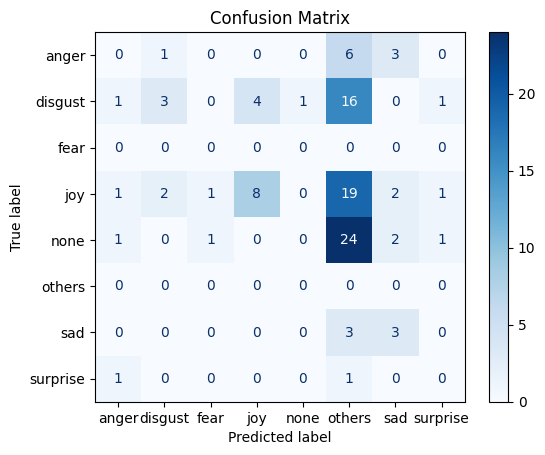

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get the unique labels from both actual and predicted labels
unique_labels = np.unique(np.concatenate((actual_labels, predicted_labels)))

# Compute the confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels, labels=unique_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# multilingual NLI model (good zero-shot cross-lingual)
clf_1 = pipeline("zero-shot-classification",
               model="joeddav/xlm-roberta-large-xnli",
               device=0)  # set device=-1 for CPU

labels = ["joy","none","disgust","anger","surprise","sad","others","fear"]

# Create lists to store actual and predicted labels
actual_labels1 = []
predicted_labels1 = []

# Sample 10% of the emotion_rn DataFrame
emotion_rn_sample = emotion_rn.sample(frac=0.1, random_state=42)

# Iterate through the sampled DataFrame
for index, row in tqdm(emotion_rn_sample.iterrows(), total=len(emotion_rn_sample)):
    text = row['text']
    actual_label = row['emotion']

    # Get predictions from the zero-shot classifier
    res = clf_1(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")

    # Get the predicted label (the one with the highest score)
    predicted_label1 = res['labels'][0]

    actual_labels1.append(actual_label)
    predicted_labels1.append(predicted_label)

# Now you have lists of actual and predicted labels, you can evaluate the performance
# For example, you can use scikit-learn's classification_report or accuracy_score
print("Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.")

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


  0%|          | 0/107 [00:00<?, ?it/s]

Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.


In [ ]:
accuracy1 = accuracy_score(actual_labels1, predicted_labels1)
print(f"Accuracy of the zero-shot classification model: {accuracy1:.4f}")

Accuracy of the zero-shot classification model: 0.0000


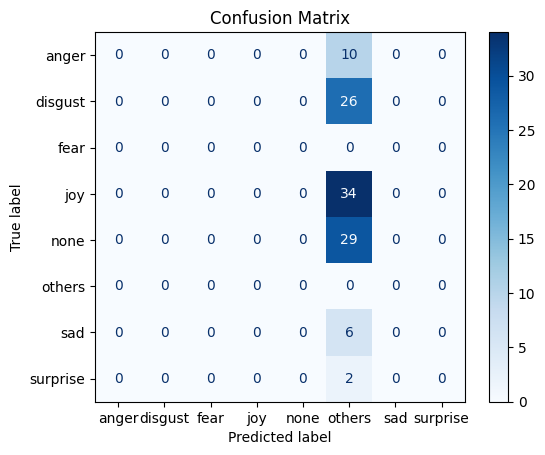

In [ ]:
# Compute the confusion matrix
cm1 = confusion_matrix(actual_labels1, predicted_labels1, labels=unique_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from transformers import pipeline
from tqdm.auto import tqdm

# multilingual NLI model (good zero-shot cross-lingual)
clf_2 = pipeline("zero-shot-classification",
               model="facebook/bart-large-mnli",
               device=0)  # set device=-1 for CPU

labels = ["joy","none","disgust","anger","surprise","sad","others","fear"]

# Create lists to store actual and predicted labels
actual_labels = []
predicted_labels = []

# Sample 10% of the emotion_rn DataFrame
emotion_rn_sample = emotion_rn.sample(frac=0.1, random_state=42)

# Iterate through the sampled DataFrame
for index, row in tqdm(emotion_rn_sample.iterrows(), total=len(emotion_rn_sample)):
    text = row['text']
    actual_label = row['emotion']

    # Get predictions from the zero-shot classifier
    res = clf_2(text, candidate_labels=labels, hypothesis_template="This text expresses {}.")

    # Get the predicted label (the one with the highest score)
    predicted_label = res['labels'][0]

    actual_labels.append(actual_label)
    predicted_labels.append(predicted_label)

# Now you have lists of actual and predicted labels, you can evaluate the performance
# For example, you can use scikit-learn's classification_report or accuracy_score
print("Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


  0%|          | 0/107 [00:00<?, ?it/s]

Finished classifying texts. You can now evaluate the results using actual_labels and predicted_labels.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"Accuracy of the zero-shot classification model: {accuracy:.4f}")

Accuracy of the zero-shot classification model: 0.1589


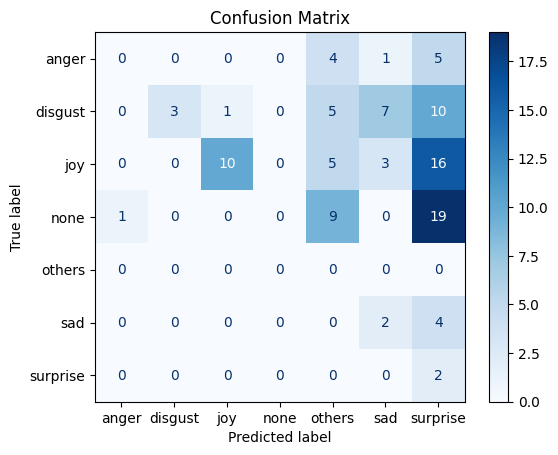

In [ ]:
# Get the unique labels from both actual and predicted labels
unique_labels = np.unique(np.concatenate((actual_labels, predicted_labels)))

# Compute the confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels, labels=unique_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()